In [2]:
import os
import json
import numpy as np
from typing import Dict, List, Tuple
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
data_path = os.path.join("data", "ecommerce_products.json")

if not os.path.exists(data_path):
    print(f"Data file not found at: {data_path}")
else:
    with open(data_path, "r", encoding="utf-8") as f:
        products = json.load(f)

    print(f"Dataset loaded successfully.")
    print(f"Number of products: {len(products)}")

Dataset loaded successfully.
Number of products: 4


In [4]:
print("\n--- E-Commerce Products ---")

for i, product in enumerate(products, start=1):
    print(f"\nProduct {i}")
    print(f"Name        : {product['name']}")
    print(f"Description : {product['description']}")


--- E-Commerce Products ---

Product 1
Name        : Wireless Noise Cancelling Headphones
Description : High fidelity sound bluetooth active noise cancellation wireless headphone with microphone.

Product 2
Name        : Bluetooth Gaming Earbuds
Description : Low latency wireless earbuds with gaming audio surround sound and mic.

Product 3
Name        : Ergonomic Mechanical Keyboard
Description : RGB mechanical keyboard blue switch tactile feel ergonomic wrist rest for gaming.

Product 4
Name        : Wireless Optical Gaming Mouse
Description : High precision DPI wireless ergonomic mouse with customizable RGB buttons.


In [5]:
corpus_tokens = [
    product["description"].lower().split()
    for product in products
]

print("\n--- Tokenized Corpus ---")

for i, tokens in enumerate(corpus_tokens, start=1):
    print(f"Product {i}: {tokens}")


--- Tokenized Corpus ---
Product 1: ['high', 'fidelity', 'sound', 'bluetooth', 'active', 'noise', 'cancellation', 'wireless', 'headphone', 'with', 'microphone.']
Product 2: ['low', 'latency', 'wireless', 'earbuds', 'with', 'gaming', 'audio', 'surround', 'sound', 'and', 'mic.']
Product 3: ['rgb', 'mechanical', 'keyboard', 'blue', 'switch', 'tactile', 'feel', 'ergonomic', 'wrist', 'rest', 'for', 'gaming.']
Product 4: ['high', 'precision', 'dpi', 'wireless', 'ergonomic', 'mouse', 'with', 'customizable', 'rgb', 'buttons.']


In [6]:
def train_word_vectors(
    corpus_tokens: List[List[str]], 
    dim: int = 50
) -> Dict[str, np.ndarray]:
    """
    Initializes word embedding vectors for the vocabulary.

    A semantic cluster is created for selected audio-related
    e-commerce terms.
    """

    vocab = list(set(
        word.lower()
        for document in corpus_tokens
        for word in document
    ))

    np.random.seed(42)

    vectors = {
        word: np.random.randn(dim)
        for word in vocab
    }

    # Semantic proximity cluster for audio equipment terms
    audio_terms = [
        "headphones",
        "earbuds",
        "bluetooth",
        "wireless",
        "sound"
    ]

    cluster_center = np.random.randn(dim)

    for term in audio_terms:
        if term in vectors:
            vectors[term] = (
                cluster_center +
                np.random.randn(dim) * 0.1
            )

    return vectors


vectors = train_word_vectors(corpus_tokens)

print("Word vectors generated successfully.")
print(f"Vocabulary size: {len(vectors)}")
print(f"Embedding dimension: {len(next(iter(vectors.values())))}")

Word vectors generated successfully.
Vocabulary size: 36
Embedding dimension: 50


In [7]:
def compute_analogy(
    vec_a: np.ndarray,
    vec_b: np.ndarray,
    vec_c: np.ndarray
) -> np.ndarray:
    """
    Computes vector analogy:

    A - B + C

    Example:
    king - man + woman ≈ queen
    """
    
    return vec_a - vec_b + vec_c

In [8]:
print("\n--- Vector Analogy Execution ---")

if all(word in vectors for word in ["king", "man", "woman"]):

    analogy_result = compute_analogy(
        vectors["king"],
        vectors["man"],
        vectors["woman"]
    )

    print("Expression: king - man + woman")
    print("Analogy Vector Shape:", analogy_result.shape)
    print("Analogy vector:")
    print(analogy_result)

else:
    print(
        "king, man, or woman is not available "
        "in the current vocabulary."
    )


--- Vector Analogy Execution ---
king, man, or woman is not available in the current vocabulary.


In [9]:
sample_words = list(vectors.keys())[:10]

sample_matrix = np.array([
    vectors[word]
    for word in sample_words
])

pca = PCA(n_components=2)

pca_2d = pca.fit_transform(sample_matrix)

print("\n--- 2D Projection Coordinates (PCA) ---")

for word, coordinate in zip(sample_words, pca_2d):
    print(
        f"Word: {word:<15} | "
        f"2D Coordinates: "
        f"({coordinate[0]:.3f}, {coordinate[1]:.3f})"
    )


--- 2D Projection Coordinates (PCA) ---
Word: rest            | 2D Coordinates: (-1.909, -3.140)
Word: wireless        | 2D Coordinates: (-5.441, 1.586)
Word: mechanical      | 2D Coordinates: (0.229, -0.357)
Word: dpi             | 2D Coordinates: (0.080, 2.774)
Word: sound           | 2D Coordinates: (-5.669, 1.382)
Word: fidelity        | 2D Coordinates: (0.921, -5.435)
Word: switch          | 2D Coordinates: (2.080, 0.671)
Word: ergonomic       | 2D Coordinates: (3.145, 2.403)
Word: wrist           | 2D Coordinates: (2.432, -3.470)
Word: and             | 2D Coordinates: (4.133, 3.586)


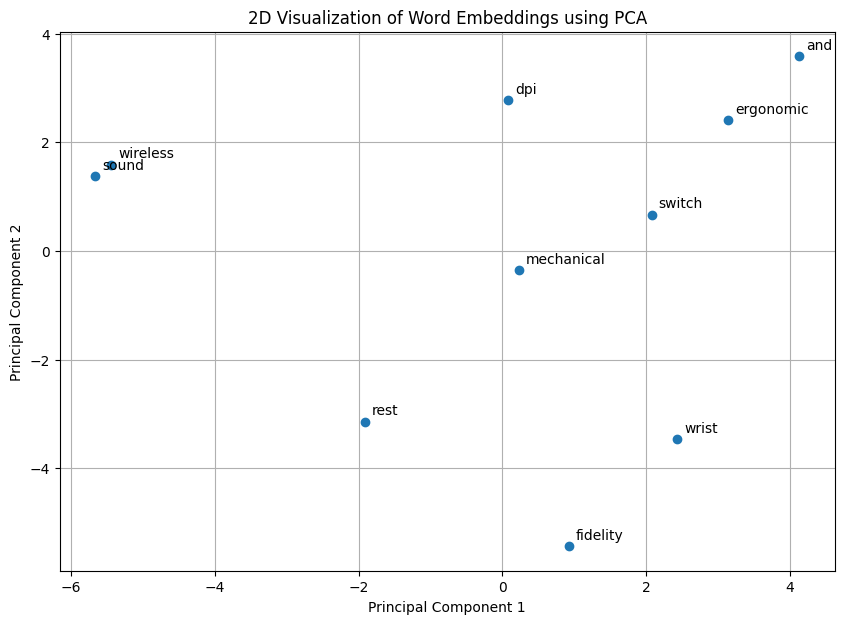

In [10]:
plt.figure(figsize=(10, 7))

plt.scatter(
    pca_2d[:, 0],
    pca_2d[:, 1]
)

for word, coordinate in zip(sample_words, pca_2d):
    plt.annotate(
        word,
        (coordinate[0], coordinate[1]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("2D Visualization of Word Embeddings using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

plt.show()

In [11]:
def recommend_products(
    query: str,
    products: List[dict],
    word_vectors: Dict[str, np.ndarray]
) -> List[Tuple[str, float]]:
    """
    Suggests semantically similar e-commerce products
    for a user search query.
    """

    q_words = query.lower().split()

    q_vecs = [
        word_vectors[word]
        for word in q_words
        if word in word_vectors
    ]

    if not q_vecs:
        return []

    query_centroid = np.mean(q_vecs, axis=0)
    query_norm = np.linalg.norm(query_centroid)

    results = []

    for product in products:

        p_tokens = (
            product["description"]
            .lower()
            .split()
        )

        p_vecs = [
            word_vectors[word]
            for word in p_tokens
            if word in word_vectors
        ]

        if p_vecs:

            document_centroid = np.mean(
                p_vecs,
                axis=0
            )

            document_norm = np.linalg.norm(
                document_centroid
            )

            if query_norm == 0 or document_norm == 0:
                similarity = 0.0
            else:
                similarity = (
                    np.dot(
                        query_centroid,
                        document_centroid
                    )
                    /
                    (query_norm * document_norm)
                )

            results.append(
                (
                    product["name"],
                    float(similarity)
                )
            )

    results.sort(
        key=lambda x: x[1],
        reverse=True
    )

    return results

In [12]:
queries = [
    "headphones",
    "wireless",
    "bluetooth",
    "earbuds",
    "sound"
]

for query in queries:

    print("\n" + "=" * 60)
    print(f"Query: {query}")
    print("=" * 60)

    recommendations = recommend_products(
        query,
        products,
        vectors
    )

    for name, score in recommendations[:5]:
        print(
            f"{name:<40} "
            f"Similarity: {score:.4f}"
        )


Query: headphones

Query: wireless
Wireless Noise Cancelling Headphones     Similarity: 0.7037
Bluetooth Gaming Earbuds                 Similarity: 0.6448
Wireless Optical Gaming Mouse            Similarity: 0.3839
Ergonomic Mechanical Keyboard            Similarity: 0.0612

Query: bluetooth
Wireless Noise Cancelling Headphones     Similarity: 0.6957
Bluetooth Gaming Earbuds                 Similarity: 0.6096
Wireless Optical Gaming Mouse            Similarity: 0.3642
Ergonomic Mechanical Keyboard            Similarity: 0.0561

Query: earbuds
Wireless Noise Cancelling Headphones     Similarity: 0.7062
Bluetooth Gaming Earbuds                 Similarity: 0.6329
Wireless Optical Gaming Mouse            Similarity: 0.3764
Ergonomic Mechanical Keyboard            Similarity: 0.0356

Query: sound
Wireless Noise Cancelling Headphones     Similarity: 0.6921
Bluetooth Gaming Earbuds                 Similarity: 0.5978
Wireless Optical Gaming Mouse            Similarity: 0.3503
Ergonomic Mechan